# Hybrid Models (Graph-Tree Integration)

This notebook summarizes **two hybrid attempts** for node classification on the Elliptic transaction graph by combining graph-based embeddings with tree-based models.

**Attempt 1:** Use the embedding matrix computed from **GPS** as additional features for a `RandomForestClassifier`. This is a simple hybrid pipeline, but the performance does not improve much over the baseline random forest.

**Attempt 2:** replace the final GNN prediction layer with a **Differentiable Neural Decision Forest (DNDF)** and train the model end-to-end. Then extract the learned embedding matrix and use it to improve a shallow random forest (`max_depth=5`).

In [2]:
import torch
from torch_geometric.data import Data

elliptic = torch.load("../Dataset/processed/transaction_graph_v1.pt", weights_only=False, map_location="cpu")
txs_data = Data(**elliptic[0])
txs_data

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

In [6]:
# Implement strict time-forward train/val/test split
time_steps = txs_data.x[:,0]
train_mask = (time_steps >= 1) & (time_steps <= 32)
val_mask = (time_steps >= 33) & (time_steps <= 37)
test_mask = (time_steps >= 38) & (time_steps <= 42)

# Select the labeled data and make the train/val/test sets
labeled = txs_data.y != 2
train_idx = train_mask & labeled
val_idx = val_mask & labeled
test_idx = test_mask & labeled

print("The size of the training set is:", train_idx.sum().item())
print("The size of the validation set is:",val_idx.sum().item())
print("The size of the testing set is:", test_idx.sum().item())

The size of the training set is: 28938
The size of the validation set is: 4503
The size of the testing set is: 6436


### Code for training and evaluation

In [8]:
feature_idx = torch.tensor(list(range(1, 93))  + [105, 115, 120, 132, 138])
x = txs_data.x[:,feature_idx]
y = txs_data.y
h = torch.load("../gnn/embeddings/gps_embeddings.pt")

# The original features
X_train_original = x[train_idx]
X_val_original = x[val_idx]
X_test_original = x[test_idx]

# The augmented features
X_hybrid = torch.cat([x, h], dim=1)
X_train_hybrid = X_hybrid[train_idx]
X_val_hybrid = X_hybrid[val_idx]
X_test_hybrid = X_hybrid[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

def evaluate(model, X):
  #X = X_hybrid if hybrid else x
  y_scores = model.predict_proba(X)[:,-1]

  # Compute precison and recall
  train_precision, train_recall, _ = precision_recall_curve(y_train, y_scores[train_idx])
  val_precision, val_recall, _ = precision_recall_curve(y_val, y_scores[val_idx])
  test_precision, test_recall, _ = precision_recall_curve(y_test, y_scores[test_idx])

  # Compute false positive rate and true positive rate
  train_fpr, train_tpr, _ = roc_curve(y_train, y_scores[train_idx])
  val_fpr, val_tpr, _  = roc_curve(y_val, y_scores[val_idx])
  test_fpr, test_tpr, _ = roc_curve(y_test, y_scores[test_idx])

  print(f'Train PR-AUC: {auc(train_recall, train_precision):.4f}. Train ROC-AUC: {auc(train_fpr, train_tpr): .4f}')
  print(f'Val PR-AUC: {auc(val_recall, val_precision):.4f}. Val ROC-AUC: {auc(val_fpr, val_tpr): .4f}')
  print(f'Test PR-AUC: {auc(test_recall, test_precision):.4f}. Test ROC-AUC: {auc(test_fpr, test_tpr): .4f}')

  # Plot the PR curve and the ROC curve
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  axes[0].plot(train_recall, train_precision, label='Training set')
  axes[0].plot(val_recall, val_precision, label='Validation set')
  axes[0].plot(test_recall, test_precision, label='Testing set')
  axes[0].set_xlabel('Recall')
  axes[0].set_ylabel('Precision')
  axes[0].set_title('Precision-Recall Curve')
  axes[0].legend()

  axes[1].plot(train_fpr, train_tpr, label='Training set')
  axes[1].plot(val_fpr, val_tpr, label='Validation set')
  axes[1].plot(test_fpr, test_tpr, label = 'Testing set')
  axes[1].plot([0, 1], [0, 1], 'k--')
  axes[1].set_xlabel('False Positive Rate')
  axes[1].set_ylabel('True Positive Rate')
  axes[1].set_title('ROC Curve')
  axes[1].legend()
  plt.show()

  return y_scores

# Evaluate the model for each time step in the testing set
# Print out PR-AUC, precision, recall and F1-score

def evaluate_by_timesteps(model, X, threshold = 0.5):
  #X = X_hybrid if hybrid else x
  y_scores = model.predict_proba(X)[:,-1]

  rows = []
  for t in range(38, 43):
    mask_t = test_idx & (time_steps == t)
    y_t = y[mask_t]
    y_scores_t = y_scores[mask_t]

    precision, recall, _ = precision_recall_curve(y_t, y_scores_t)
    pr_auc = auc(recall, precision)

    y_pred_t = (y_scores_t >= threshold).astype(int)
    p = precision_score(y_t, y_pred_t, zero_division = 0)
    r = recall_score(y_t, y_pred_t, zero_division = 0)
    f1 = f1_score(y_t, y_pred_t, zero_division = 0)

    rows.append({"time_step": t, "pr-auc": f"{pr_auc:.4f}",
    f"precision(threshold = {threshold})": f"{p:.4f}",
    f"recall(threshold = {threshold})": f"{r:.4f}",
    f"f1(threshold = {threshold})": f"{f1:.4f}"})

  return pd.DataFrame(rows)

### Non-hybrid Random Forest

We look at the performance of a Random Forest that is trained on node-only features. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth = 19,
                            max_features = 'sqrt',
                            min_samples_leaf = 5,
                            min_samples_split=10,
                            class_weight='balanced',
                            n_estimators=200,
                            random_state=42)

rf.fit(X_train_original, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=19,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

Train PR-AUC: 0.9993. Train ROC-AUC:  0.9999
Val PR-AUC: 0.9452. Val ROC-AUC:  0.9854
Test PR-AUC: 0.8955. Test ROC-AUC:  0.9557


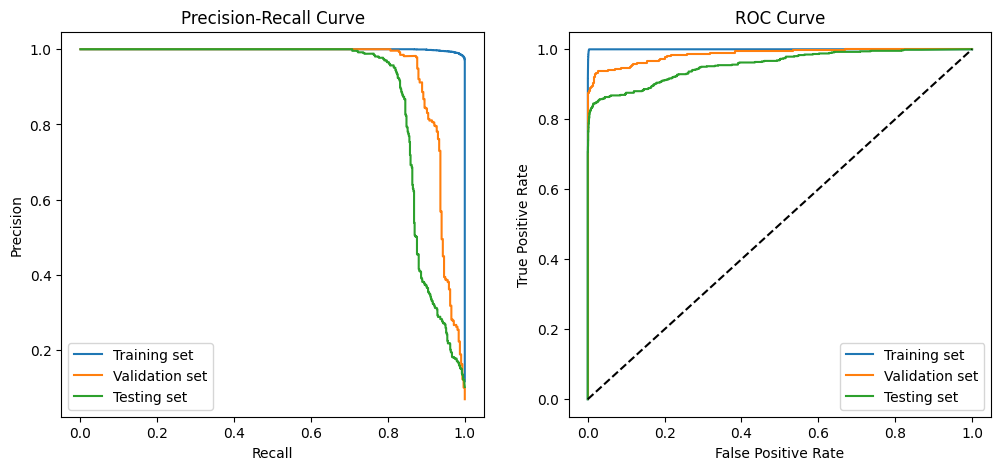

In [ ]:
_ = evaluate(rf, x)

In [ ]:
evaluate_by_timesteps(rf, x)

,time_step,pr-auc,precision(threshold = 0.5),recall(threshold = 0.5),f1(threshold = 0.5)
0,38,0.9479,0.9444,0.9189,0.9315
1,39,0.9525,0.8152,0.9259,0.8671
2,40,0.7511,0.7835,0.6786,0.7273
3,41,0.9606,0.9016,0.9483,0.9244
4,42,0.8813,0.8700,0.8117,0.8398


In [ ]:
import joblib
#joblib.dump(rf, "../gnn/models/best_rf.pkl")

Now let's see how we can improve the models' performance by adopting hybrid architectures. 

### Hybrid Attempt 1 (GPS embeddings + Random Forest)

We compute GPS-based node embedding vectors and concatenate them with the original features, then train a `RandomForestClassifier`. 

In [ ]:
# Hyperparameter turning
import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score
from tqdm import tqdm

params = {
    'n_estimators': [200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5],
    'min_samples_split': [10],
    'max_features': ['sqrt', 0.3, 0.5],
    'class_weight': [None, 'balanced']
}

best_param, best_val_ap = None,-np.inf

grid = list(ParameterGrid(params))

for param in tqdm(grid, desc = 'Progress bar'):
  rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)
  rf.fit(X_train_hybrid, y_train)

  y_val_scores = rf.predict_proba(X_val_hybrid)[:,-1]
  val_ap = average_precision_score(y_val, y_val_scores)

  if val_ap > best_val_ap:
    best_param, best_val_ap = param, val_ap

print("The best param is", best_param)
print(f"The average precison on the validation set is {best_val_ap:.2f}")

In [ ]:
rf_hybrid = RandomForestClassifier(max_depth = 19,
                                   max_features = 'sqrt',
                                   min_samples_leaf = 5,
                                   min_samples_split = 10,
                                   class_weight = 'balanced',
                                   n_estimators = 200,
                                   random_state = 42)
rf_hybrid.fit(X_train_hybrid, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=19,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

Train PR-AUC: 0.9995. Train ROC-AUC:  0.9999
Val PR-AUC: 0.9142. Val ROC-AUC:  0.9722
Test PR-AUC: 0.8711. Test ROC-AUC:  0.9463


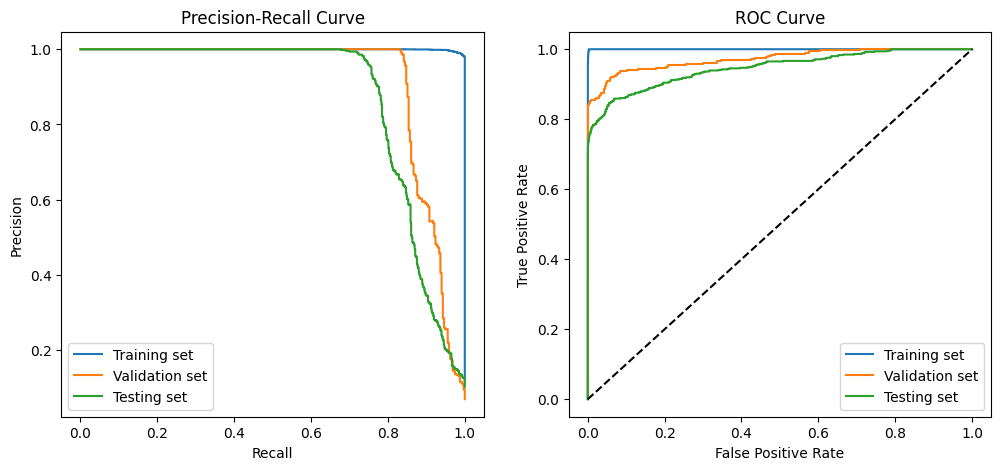

In [ ]:
_ = evaluate(rf_hybrid, X_hybrid)

In [ ]:
evaluate_by_timesteps(rf_hybrid, X_hybrid)

,time_step,pr-auc,precision(threshold = 0.5),recall(threshold = 0.5),f1(threshold = 0.5)
0,38,0.9240,0.5127,0.9099,0.6558
1,39,0.9406,0.5423,0.9506,0.6906
2,40,0.7359,0.5704,0.6875,0.6235
3,41,0.9139,0.5670,0.9483,0.7097
4,42,0.8743,0.7823,0.8117,0.7967


The results did not improve over the baseline RF, which motivates an end-to-end learned embedding approach.

### Attempt 2 (end-to-end embedding learning)

Instead of fixed GPS embeddings, we train a GNN whose final layer is replaced by a differentiable decision tree (DNDF). After training, we extract the learned node embeddings and use them to train a Random Forest. We implement DNDF as follows. 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GPSConv

def build_tree_paths(depth):
    device = torch.device("cuda")

    num_leaves = 2 ** depth
    num_decision_nodes = 2 ** depth - 1

    path_mask = torch.zeros(num_leaves, num_decision_nodes, dtype=torch.bool, device=device)
    go_left = torch.zeros(num_leaves, num_decision_nodes, dtype=torch.bool, device=device)

    for leaf in range(num_leaves):
        node = 0
        for level in range(depth):
            bit = (leaf >> (depth - 1 - level)) & 1
            path_mask[leaf, node] = True
            go_left[leaf, node] = (bit == 0)

            if bit == 0:
                node = 2 * node + 1
            else:
                node = 2 * node + 2

    return path_mask, go_left

class TreeHead(nn.Module):
    def __init__(self, hidden_dim, num_classes, depth=3):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.depth = depth

        self.num_leaves = 2 ** depth
        self.num_decision_nodes = 2 ** depth - 1

        self.decision_layer = nn.Linear(hidden_dim, self.num_decision_nodes)
        self.leaf_logits = nn.Parameter(torch.randn(self.num_leaves, num_classes) * 0.01)

        path_mask, go_left = build_tree_paths(depth)
        self.register_buffer("path_mask", path_mask)
        self.register_buffer("go_left", go_left)

    def compute_mu(self, h):
        decision_logits = self.decision_layer(h)
        decision_probs = torch.sigmoid(decision_logits)

        d = decision_probs.unsqueeze(1)
        path_mask = self.path_mask.unsqueeze(0)
        go_left = self.go_left.unsqueeze(0)

        chosen = torch.where(go_left, d, 1.0 - d)
        chosen = torch.where(path_mask, chosen, torch.ones_like(chosen))

        mu = chosen.prod(dim=-1)
        return mu

    def forward(self, h):
        mu = self.compute_mu(h)
        leaf_probs = F.softmax(self.leaf_logits, dim=1)

        probs = mu @ leaf_probs
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-12)

        logits = torch.log(probs.clamp_min(1e-12))
        return logits

    @torch.no_grad()
    def update_leaf_distributions(self, h_train, y_train, n_iter=20):
        mu = self.compute_mu(h_train)
        pi = F.softmax(self.leaf_logits, dim=1)

        y_onehot = F.one_hot(y_train, num_classes=self.num_classes).float()

        for _ in range(n_iter):
            probs = (mu @ pi).clamp_min(1e-12)
            p_true = probs.gather(1, y_train.unsqueeze(1)).squeeze(1)
            pi_true = pi[:, y_train].T

            weight = (pi_true * mu) / p_true.unsqueeze(1)
            numer = weight.T @ y_onehot

            pi = numer / numer.sum(dim=1, keepdim=True).clamp_min(1e-12)

        self.leaf_logits.data.copy_(torch.log(pi.clamp_min(1e-12)))

class DNDF(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, tree_depth=3, num_heads=4, dropout=0.0, attn_dropout=0.0,):
        super().__init__()

        self.input_proj = nn.Linear(in_channels, hidden_channels)

        # Local MPNN used inside each GPS layer
        local_mpnn1 = SAGEConv(hidden_channels, hidden_channels)
        local_mpnn2 = SAGEConv(hidden_channels, hidden_channels)

        self.gps1 = GPSConv(channels=hidden_channels, conv=local_mpnn1, heads=num_heads, dropout=attn_dropout, attn_type="performer",)
        self.gps2 = GPSConv(channels=hidden_channels, conv=local_mpnn2, heads=num_heads, dropout=attn_dropout, attn_type="performer",)
        self.dropout = dropout

        self.tree_head = TreeHead(hidden_dim=hidden_channels, num_classes=num_classes, depth=tree_depth,)

    def encode(self, x, edge_index, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        h = self.input_proj(x)
        h= self.gps1(h, edge_index, batch=batch)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.gps2(h, edge_index, batch=batch)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        return h

    def forward(self, x, edge_index, batch=None, return_embeddings=False):
        h = self.encode(x, edge_index, batch=batch)
        logits = self.tree_head(h)

        if return_embeddings:
            return logits, h
        return logits

    @torch.no_grad()
    def update_leaf_distributions(self, x, edge_index, y, train_idx, batch=None, n_iter=20):
        self.eval()
        h = self.encode(x, edge_index, batch=batch)
        h_train = h[train_idx]
        y_train = y[train_idx]
        self.tree_head.update_leaf_distributions(h_train, y_train, n_iter=n_iter)

### Preparing the data

In [ ]:
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import StandardScaler

edge_index = txs_data.edge_index
edge_index_undir = to_undirected(edge_index) #conversion to undirected graph

# Feature scaling
mean = x[train_idx].mean(0, keepdim=True)
std = x[train_idx].std(0, keepdim=True)
x_transformed = (x - mean) / (std + 1e-8)

# Store the dataset on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_gpu = x_transformed.to(device)
y_gpu = y.to(device)
edge_index_undir_gpu = edge_index_undir.to(device)

# Use timestep 35 - 37 for validation (model achieves its best performance in experiements)
dndf_val_mask = (time_steps >= 35) & (time_steps <= 37)
dndf_val_idx = dndf_val_mask & labeled

train_idx_gpu = train_idx.to(device)
val_idx_gpu = dndf_val_idx.to(device)
test_idx_gpu = test_idx.to(device)

# Compute class weights from train labels
y_train_gpu = y_gpu[train_idx_gpu]
nums_0 = (y_train_gpu == 0).sum().item()
nums_1 = (y_train_gpu == 1).sum().item()

w0 = 1.0
w1 = nums_0/max(nums_1, 1)
class_weight = torch.tensor([w0, w1], device = device)

### Training

In [ ]:
import copy
import random
import numpy as np
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import average_precision_score
from IPython.display import clear_output

# Set random seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

def train_dndf(model, training_params: dict):
    lr, weight_decay, patience, min_delta, factor, threshold, epochs = training_params.values()
    pi_iters = 20

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=int(0.5 * patience), factor=factor, threshold=threshold)

    best_val_ap, best_state = -1, None
    bad_epochs = 0

    for epoch in range(epochs):

        model.eval()
        with torch.no_grad():
            model.update_leaf_distributions(x_gpu, edge_index_undir_gpu, y_gpu, train_idx_gpu, n_iter=pi_iters)

        model.train()
        optimizer.zero_grad()

        logits = model(x_gpu, edge_index_undir_gpu)
        loss = F.cross_entropy(logits[train_idx_gpu], y_gpu[train_idx_gpu], weight=class_weight)

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(x_gpu, edge_index_undir_gpu)
            val_prob = F.softmax(logits[val_idx_gpu], dim=1)[:, 1]
            val_ap = average_precision_score(y[dndf_val_idx], val_prob.cpu().numpy())

        scheduler.step(val_ap)

        if val_ap > best_val_ap + min_delta:
            best_val_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{epochs}, "f"Loss: {loss.item():.4f}, "f"val_ap: {val_ap:.4f}")

    model.load_state_dict(best_state)
    print("Best average precision on the validation set (timesteps 35 - 37) is", best_val_ap)
    return model

### Evaluation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, precision_score, recall_score, f1_score

# Convert Torch tensors to NumPy arrays
y_np = y.numpy()
train_idx_np = train_idx.numpy()
val_idx_np = val_idx.numpy()
test_idx_np = test_idx.numpy()
time_np = time_steps.numpy()


# Evaluate the model on the entire dataset
def evaluate_dndf(model):
  with torch.no_grad():
    logits = model(x_gpu, edge_index_undir_gpu, return_embeddings=False)
    y_scores = F.softmax(logits, dim=1)[:,1]

    # Move tensors from GPU to CPU, and convert to NumPy arrays
    y_scores_np = y_scores.detach().cpu().numpy()

  # Compute precision and recall for training/validation/testing sets
  train_precision, train_recall, _ = precision_recall_curve(y_np[train_idx_np], y_scores_np[train_idx_np])
  val_precision, val_recall, _ = precision_recall_curve(y_np[val_idx_np], y_scores_np[val_idx_np])
  test_precision, test_recall, _ = precision_recall_curve(y_np[test_idx_np], y_scores_np[test_idx_np])
  print(f'The PR-AUC on the training set is: {auc(train_recall, train_precision):.4f}')
  print(f'The PR-AUC on the validation set is: {auc(val_recall, val_precision):.4f} ')
  print(f'The PR-AUC on the testing set is: {auc(test_recall, test_precision):.4f} ')

  plt.plot(train_recall, train_precision, label='Training set')
  plt.plot(val_recall, val_precision, label='Validation set')
  plt.plot(test_recall, test_precision, label='Testing set')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision-Recall Curve')
  plt.legend()
  plt.show()

  return y_scores_np

# Evaluate the performance for each time step in the testing set
def evaluate_by_timesteps_dndf(model, threshold = 0.5):
  with torch.no_grad():
    logits = model(x_gpu, edge_index_undir_gpu, return_embeddings=False)
    y_scores = F.softmax(logits, dim=1)[:,1]
    y_scores_np = y_scores.detach().cpu().numpy()

  rows = []
  for t in range(38, 43):
    mask_t = test_idx_np & (time_np == t)
    y_t = y_np[mask_t]
    y_scores_t = y_scores_np[mask_t]

    precision, recall, _ = precision_recall_curve(y_t, y_scores_t)
    pr_auc = auc(recall, precision)

    y_pred_t = (y_scores_t >= threshold).astype(int)
    p = precision_score(y_t, y_pred_t, zero_division = 0)
    r = recall_score(y_t, y_pred_t, zero_division = 0)
    f1 = f1_score(y_t, y_pred_t, zero_division = 0)


    rows.append({"time_step": t, "pr-auc": f"{pr_auc:.4f}",
    f"precision(p={threshold})": f"{p:.4f}",
    f"recall(p={threshold})": f"{r:.4f}",
    f"f1(p={threshold})": f"{f1:.4f}",
    f"illicit rate": f"{(y_t == 1).sum()/len(y_t):.4f}"})

  return pd.DataFrame(rows)

# Retrive the embedding matrix
def get_embeddings(model):
  model.eval()
  with torch.no_grad():
    _, h = model(x_gpu, edge_index_undir_gpu, return_embeddings=True)
    h = h.detach().cpu()
  return h

### Training and evaluating DNDF

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
set_seed(7)
dndf = DNDF(in_channels=x.size(1), hidden_channels= 16, num_classes=2, tree_depth= 5, num_heads= 4, dropout=0.3, attn_dropout=0.1).to(device)
training_params = {'Learning rate': 1e-3, 'Weight decay': 5e-3, # optimizer hyperparamters
          'Patience': 10, 'Min Delta': 1e-4, # early stopping hyperparameters
          'Factor': 0.5, 'Threshold': 1e-3, # scheduler hyperparameters
          'Epochs':100} # total number of epochs
trained_dndf = train_dndf(dndf, training_params)

Epoch 80/100, Loss: 0.5559, val_ap: 0.9234
Best average precision on the validation set (timesteps 35 - 37) is 0.9240724675811175


The PR-AUC on the training set is: 0.9113
The PR-AUC on the validation set is: 0.8793 
The PR-AUC on the testing set is: 0.8647 


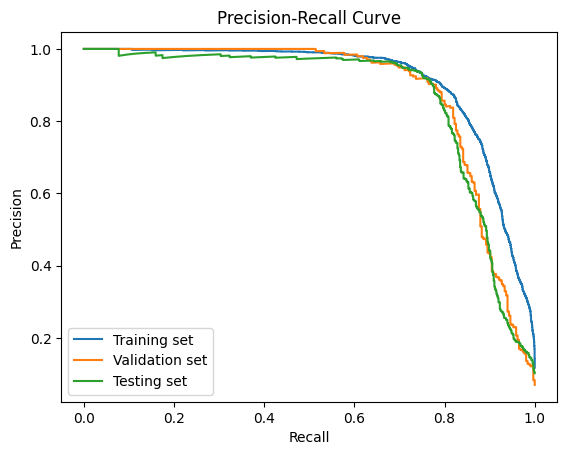

array([0.05217379, 0.09132313, 0.13554808, ..., 0.07945888, 0.11011914,
       0.10998604], dtype=float32)

In [ ]:
evaluate_dndf(trained_dndf)

In [ ]:
#torch.save(trained_dndf.state_dict(), "../gnn/models/best_dndf.pt")

In [ ]:
# Get the embedding matrix
h_dndf = get_embeddings(trained_dndf)
#torch.save(h_dndf, "../gnn/embeddings/dndf_embeddings.pt")
print("The embedding matrix has dimension", h_dndf.shape)
h_dndf

The embedding matrix has dimension torch.Size([203769, 16])


tensor([[0.0000, 0.0000, 0.0000,  ..., 0.4327, 0.1632, 0.0000],
        [0.0000, 0.0000, 0.1370,  ..., 0.0000, 0.4467, 0.0000],
        [0.0000, 0.0000, 0.2370,  ..., 0.0000, 0.6064, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0605,  ..., 0.0000, 0.0818, 0.0000],
        [0.0000, 0.0000, 0.2166,  ..., 0.0000, 0.6104, 0.0000],
        [0.0000, 0.0000, 0.2205,  ..., 0.0000, 0.7447, 0.0000]])

### The final model

Let's use the 16-dimensional embedding as additional features to train a Random Forest. In the following codes, `rf_0` is a Random Forest trained on node-only features, and `rf_1` is the same Random Forest trained on hybrid features. 

In [ ]:
# The augmented features
#h = torch.load("../gnn/embeddings/dndf_embeddings.pt")
h = h_dndf
X_final = torch.cat([txs_data.x[:,1:], h], dim=1)
X_train_final = X_final[train_idx]
X_val_final = X_final[val_idx]
X_test_final = X_final[test_idx]

Train PR-AUC: 0.9775. Train ROC-AUC:  0.9952
Val PR-AUC: 0.9396. Val ROC-AUC:  0.9797
Test PR-AUC: 0.8911. Test ROC-AUC:  0.9519


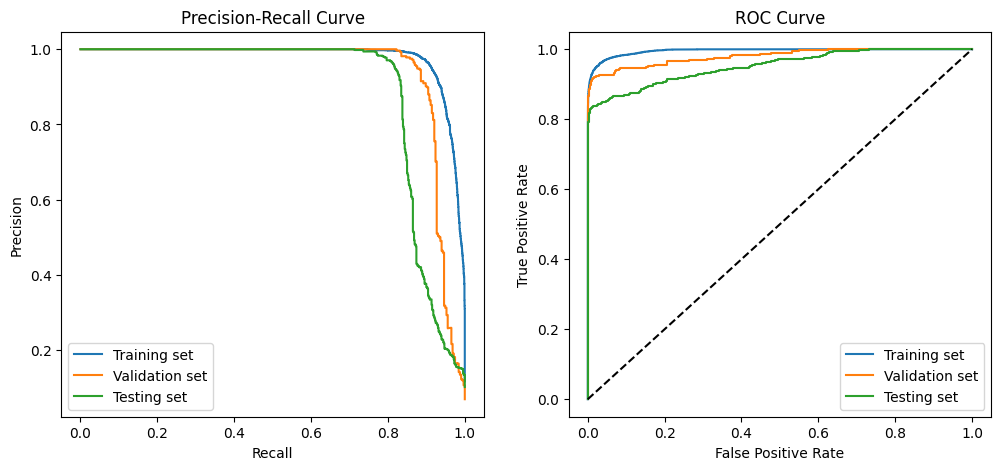

In [ ]:
param = {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

rf_0 = RandomForestClassifier(**param, random_state = 46)
rf_0.fit(txs_data.x[train_idx,1:], y_train)

_ = evaluate(rf_0, txs_data.x[:,1:])

Train PR-AUC: 0.9762. Train ROC-AUC:  0.9947
Val PR-AUC: 0.9368. Val ROC-AUC:  0.9836
Test PR-AUC: 0.8982. Test ROC-AUC:  0.9623


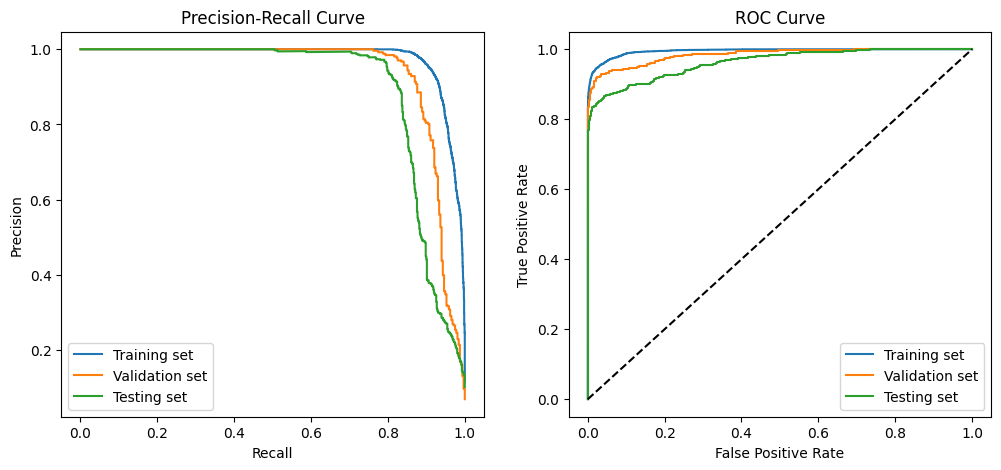

In [ ]:
rf_1 = RandomForestClassifier(**param, random_state = 46)
rf_1.fit(X_train_final, y_train)

_ = evaluate(rf_1, X_final)

As we can see, `rf_1` outperfomrs `rf_0`. This is a good sign! This shows end-to-end training is an effective way of improving hybrid models' performance. Finally, let's analyze the feature importance of `rf_1`.

In [ ]:
imp = rf_1.feature_importances_
indices = np.argsort(imp)[::-1]
mag_20 = indices[:20]
print("The 20 most important features are ")
for ind in mag_20:
  print(f"Feature {ind+1}")

The 20 most important features are 
Feature 177
Feature 168
Feature 175
Feature 180
Feature 171
Feature 181
Feature 174
Feature 173
Feature 176
Feature 53
Feature 41
Feature 178
Feature 55
Feature 172
Feature 5
Feature 179
Feature 170
Feature 47
Feature 169
Feature 43


As we can see, 14 features come from the embedding matrix! This means our embedding matrix efficiently captures the topological information of the graph.